# Task 2 - Customer Segmentation

Grouping mall customers by annual income and spending score using K-Means clustering.
Dataset: Mall Customer Segmentation Data from Kaggle (200 customers).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Loading the data

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Understanding the data
No missing values and no duplicates, so no cleaning was needed. I renamed the long column names to make them easier to use.

In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.rename(columns={
    "Annual Income (k$)": "Income",
    "Spending Score (1-100)": "Spending"
})
df.head()

,CustomerID,Gender,Age,Income,Spending
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Visualisation
In the scatter plot you can already see around 5 groups of customers.

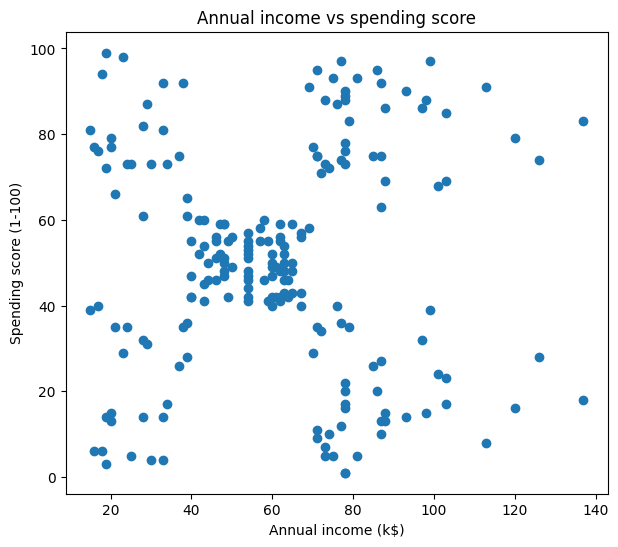

In [9]:
plt.figure(figsize=(7, 6))
plt.scatter(df["Income"], df["Spending"])
plt.title("Annual income vs spending score")
plt.xlabel("Annual income (k$)")
plt.ylabel("Spending score (1-100)")
plt.show()

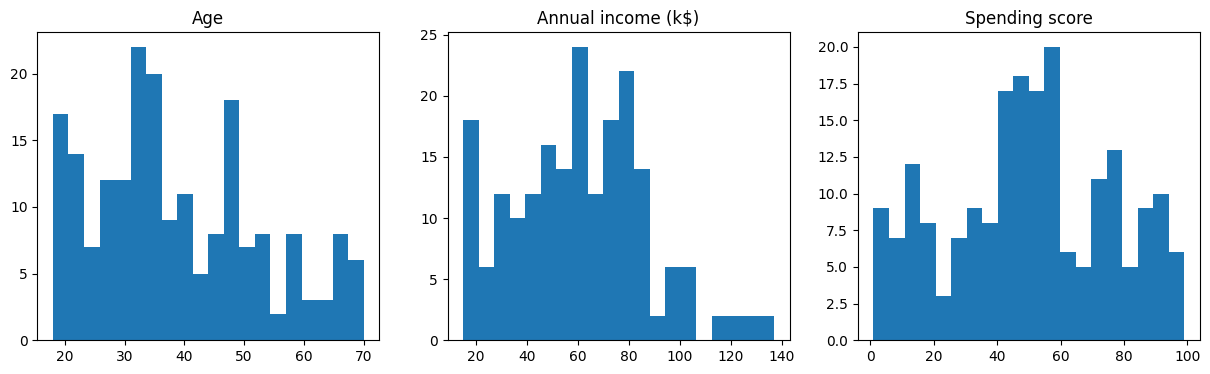

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["Age"], bins=20)
axes[0].set_title("Age")

axes[1].hist(df["Income"], bins=20)
axes[1].set_title("Annual income (k$)")

axes[2].hist(df["Spending"], bins=20)
axes[2].set_title("Spending score")

plt.show()

## 4. Scaling
K-Means uses distances, so I scaled income and spending to the same scale.

In [11]:
from sklearn.preprocessing import StandardScaler

X = df[["Income", "Spending"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])
print("Mean:", X_scaled.mean(axis=0).round(2))
print("Std:", X_scaled.std(axis=0).round(2))

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]
Mean: [-0. -0.]
Std: [1. 1.]


## 5. Choosing the number of clusters
Using the elbow method and the silhouette score.

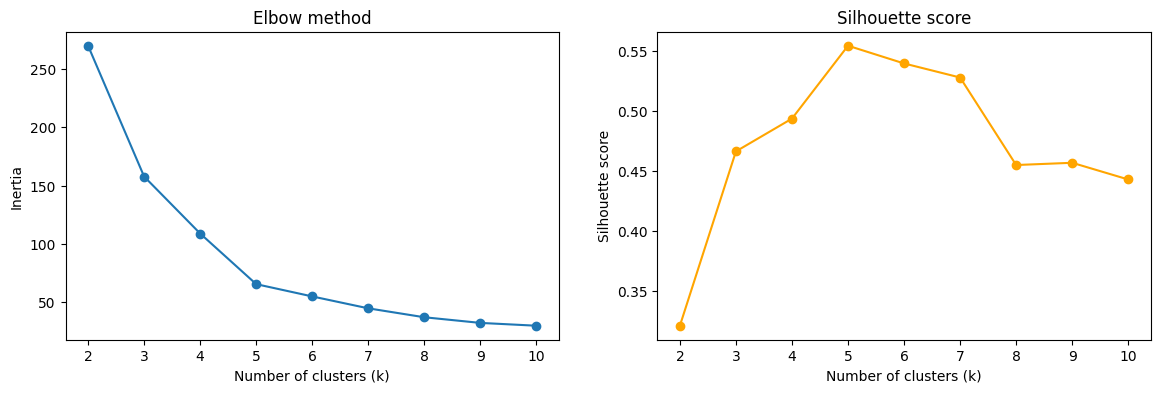

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(k_values, inertias, marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_values, silhouettes, marker="o", color="orange")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.show()

## 6. K-Means with 5 clusters
Both methods showed that 5 clusters is the best choice.

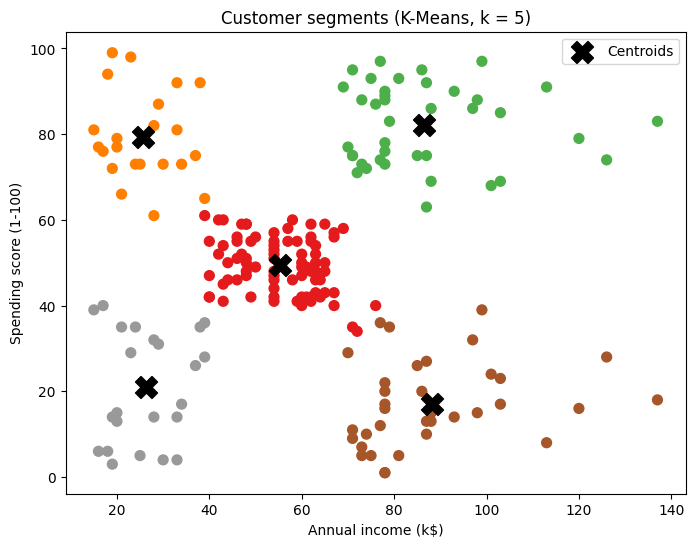

Silhouette score: 0.555


In [13]:
kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
plt.scatter(df["Income"], df["Spending"], c=df["Cluster"], cmap="Set1", s=50)
plt.scatter(centers[:, 0], centers[:, 1], c="black", marker="X", s=250, label="Centroids")
plt.title("Customer segments (K-Means, k = 5)")
plt.xlabel("Annual income (k$)")
plt.ylabel("Spending score (1-100)")
plt.legend()
plt.show()

print("Silhouette score:", round(silhouette_score(X_scaled, df["Cluster"]), 3))

## 7. Cluster summary

In [14]:
summary = df.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Income=("Income", "mean"),
    Avg_Spending=("Spending", "mean"),
    Avg_Age=("Age", "mean")
).round(1)

summary

,Customers,Avg_Income,Avg_Spending,Avg_Age
Cluster,,,,
0,81,55.3,49.5,42.7
1,39,86.5,82.1,32.7
2,22,25.7,79.4,25.3
3,35,88.2,17.1,41.1
4,23,26.3,20.9,45.2


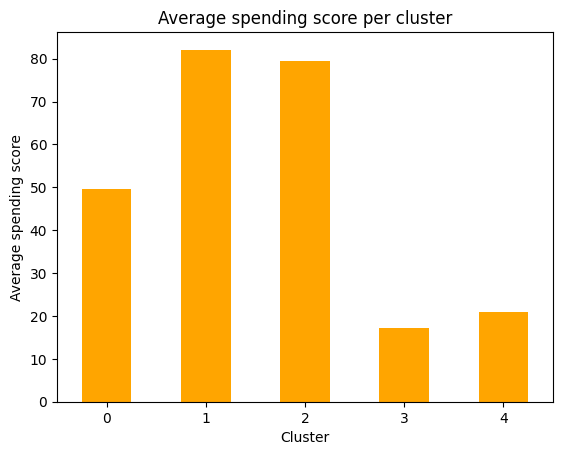

In [15]:
summary["Avg_Spending"].plot(kind="bar", color="orange")
plt.title("Average spending score per cluster")
plt.xlabel("Cluster")
plt.ylabel("Average spending score")
plt.xticks(rotation=0)
plt.show()

## 8. Bonus - DBSCAN

DBSCAN
-1    23
 0    16
 1    12
 2     7
 3    88
 4    31
 5    23
Name: count, dtype: int64


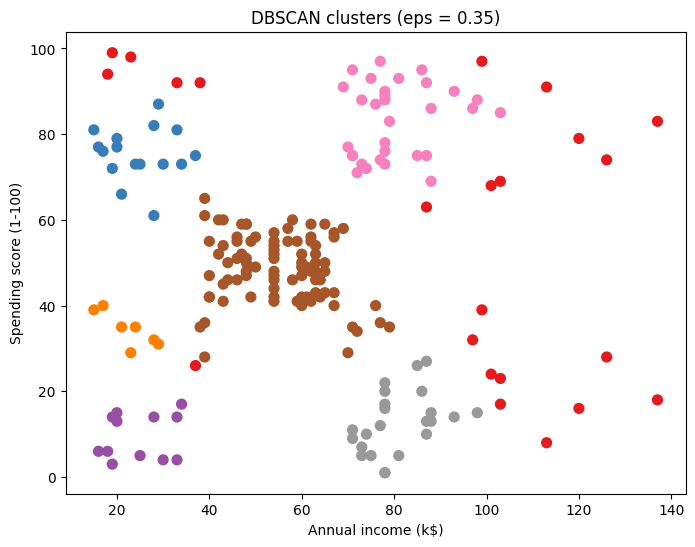

In [16]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.35, min_samples=5)
df["DBSCAN"] = dbscan.fit_predict(X_scaled)

print(df["DBSCAN"].value_counts().sort_index())

plt.figure(figsize=(8, 6))
plt.scatter(df["Income"], df["Spending"], c=df["DBSCAN"], cmap="Set1", s=50)
plt.title("DBSCAN clusters (eps = 0.35)")
plt.xlabel("Annual income (k$)")
plt.ylabel("Spending score (1-100)")
plt.show()

In [17]:
mask = df["DBSCAN"] != -1

print("K-Means silhouette:", round(silhouette_score(X_scaled, df["Cluster"]), 3))
print("DBSCAN silhouette (without noise):", round(silhouette_score(X_scaled[mask], df.loc[mask, "DBSCAN"]), 3))
print("DBSCAN noise points:", (~mask).sum())

K-Means silhouette: 0.555
DBSCAN silhouette (without noise): 0.558
DBSCAN noise points: 23


## Conclusion

The data had 200 customers with no missing values or duplicates, so no cleaning was needed.
I used annual income and spending score for clustering and scaled them with StandardScaler.

The elbow method and the silhouette score both showed that 5 clusters is the best choice
(silhouette = 0.555), which also matches the 5 groups you can see in the scatter plot.

The 5 customer groups:
- Cluster 0: average income, average spending (81 customers) - the biggest group
- Cluster 1: high income, high spending (39) - the best customers, mostly around 33 years old
- Cluster 2: low income, high spending (22) - the youngest group, around 25 years old
- Cluster 3: high income, low spending (35) - they can afford more but don't spend much here
- Cluster 4: low income, low spending (23) - careful spenders

The high income / low spending group is the biggest opportunity for the mall.
Also, income alone does not decide spending, because the two richest groups behave
in opposite ways.

DBSCAN found 6 clusters but marked 23 customers as noise, mostly customers with very
high income. Its silhouette score was 0.558 but only for the customers it grouped.
K-Means is better for this task because it puts every customer into a group.